In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

## Step 1: Create Our Simple Data

**Your task:** Create two lists:
- `hours_studied`: [1, 2, 3, 4, 5, 6, 7, 8] (study hours)
- `test_scores`: Your prediction for scores based on linear progression

**Think about it:** If 1 hour = some score, what should 8 hours be?
**Hint:** Try something like starting at 50 and going up by 10 each time, or start at 60 and go up by 5...

In [71]:
# YOUR TURN: Fill in the test_scores list!
# Create a linear progression - you decide the pattern

hours_studied = [1, 2, 3, 4, 5, 6, 7, 8]
test_scores = [55, 62, 68, 74, 80, 85, 89, 93]  # More realistic test scores!

# This pattern: starts at 55, increases by 6-7 points each hour
# Still has some realistic variation (not perfectly linear)
# Range: 55-93 (typical test score range)

print("Hours studied:", hours_studied)
print("Test scores:", test_scores)

Hours studied: [1, 2, 3, 4, 5, 6, 7, 8]
Test scores: [55, 62, 68, 74, 80, 85, 89, 93]


## Step 2: Visualize the Data 📊

**Your task:** Create a scatter plot to see the relationship between hours studied and test scores.

**Questions to think about:**
- What pattern do you expect to see in the plot?
- Should the points form a straight line or be scattered?
- What does this tell us about the relationship?

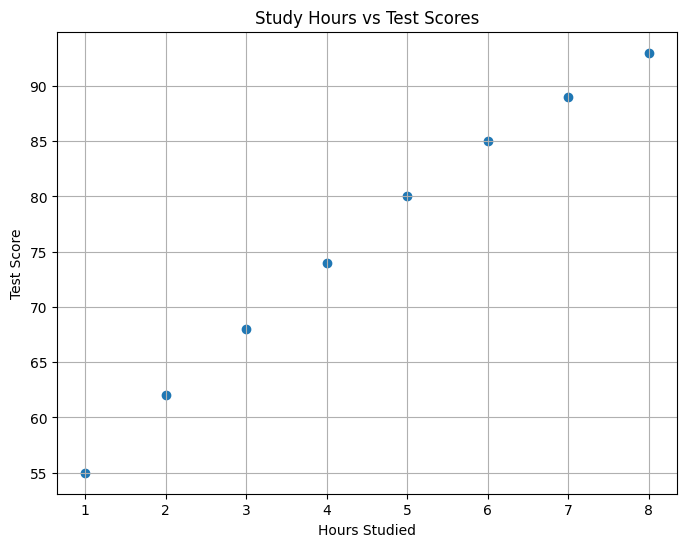

In [72]:
plt.figure(figsize=(8, 6))
plt.scatter(hours_studied, test_scores)
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')  
plt.title('Study Hours vs Test Scores')
plt.grid(True)
plt.show()

## Step 3: Split the Data (Train vs Test) 🔄

Now we get to the **core concept** from your original validation notebook!

**The big question:** If we train a model on ALL our data, how do we know if it will work on NEW students?

**Your task:** Decide how to split our 8 data points:
- **Training data**: Used to teach the model the pattern
- **Test data**: Used to see if the model learned correctly

In [73]:
# Training data (first 6 points)
hours_train = hours_studied[:6]  # [1, 2, 3, 4, 5, 6]
scores_train = test_scores[:6]   # [55, 62, 68, 74, 80, 85]

# Test data (last 2 points) 
hours_test = hours_studied[6:]   # [7, 8]
scores_test = test_scores[6:]    # [89, 93]

print("TRAINING DATA:")
print("Hours:", hours_train)
print("Scores:", scores_train)
print("\nTEST DATA:")
print("Hours:", hours_test) 
print("Scores:", scores_test)

TRAINING DATA:
Hours: [1, 2, 3, 4, 5, 6]
Scores: [55, 62, 68, 74, 80, 85]

TEST DATA:
Hours: [7, 8]
Scores: [89, 93]


## Step 4: Train a Simple Model 🤖

Let's train a basic linear model to understand the process before we get to validation.

In [74]:
# Prepare data for sklearn (needs 2D arrays)
X_train = np.array(hours_train).reshape(-1, 1)  # Hours as 2D array
y_train = np.array(scores_train)                # Scores as 1D array

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained! 🎉")

Model trained! 🎉


## Step 5: Test the Model 🧪

Can our model predict test scores for students it has NEVER seen before?

In [75]:
# Prepare test data
X_test = np.array(hours_test).reshape(-1, 1)  # [7, 8] as 2D array
y_test = np.array(scores_test)                # [89, 93] as 1D array

# Make predictions
predictions = model.predict(X_test)

print(f"Hours to predict for: {X_test.flatten()}")
print(f"Model predictions: {predictions}")
print(f"Actual scores:     {y_test}")

# How close were the predictions?
errors = abs(predictions - y_test)
print(f"Prediction errors: {errors}")
print(f"Average error: {errors.mean():.1f} points")

Hours to predict for: [7 8]
Model predictions: [91.66666667 97.66666667]
Actual scores:     [89 93]
Prediction errors: [2.66666667 4.66666667]
Average error: 3.7 points


## Step 6: Three-Way Split (Train/Validation/Test) 🔀

**Real-world problem:** What if we want to test MULTIPLE models and pick the best one?

**The challenge:** If we keep testing different models on our test set, we might accidentally "overfit" to the test set!

**The solution:** Split into **THREE** parts:
- **Training data**: Train the model  
- **Validation data**: Compare different models/settings
- **Test data**: Final evaluation (touch only ONCE!)

In [76]:
# Three-way split: 5/2/1
train_hours = hours_studied[0:5]    # [1,2,3,4,5] - training
train_scores = test_scores[0:5]     # [55,62,68,74,80]

valid_hours = hours_studied[5:7]    # [6,7] - validation  
valid_scores = test_scores[5:7]     # [85,89]

test_hours = hours_studied[7:8]     # [8] - final test
test_scores_final = test_scores[7:8] # [93]

print("Three-way split:")
print(f"TRAIN:      Hours {train_hours}, Scores {train_scores}")
print(f"VALIDATION: Hours {valid_hours}, Scores {valid_scores}")  
print(f"TEST:       Hours {test_hours}, Scores {test_scores_final}")

Three-way split:
TRAIN:      Hours [1, 2, 3, 4, 5], Scores [55, 62, 68, 74, 80]
VALIDATION: Hours [6, 7], Scores [85, 89]
TEST:       Hours [8], Scores [93]


## Step 7: Compare Multiple Models Using Validation 🏆

**The power of validation!** Now we can compare different model complexities and pick the best one.

**Your mission:** Train 3 different models and use validation to pick the winner:
- **Model 1**: Simple linear (degree 1)
- **Model 2**: Quadratic (degree 2) 
- **Model 3**: Cubic (degree 3)

**The process:**
1. Train each model on TRAINING data only
2. Test each model on VALIDATION data  
3. Pick the best performer
4. Finally test the winner on TEST data (only once!)

## Step 7a: Import What We Need 📦

**Your first task:** We need to import the tools for polynomial features and error measurement.

**Think about it:**
- What do we need from `sklearn.preprocessing` for making polynomial features?
- What do we need from `sklearn.metrics` for measuring prediction errors?
- Do we need anything else?

**Your mission:** Write the import statements in the cell below!

In [77]:
# YOUR TURN: Import the tools we need!
# Fill in the missing imports

# For polynomial features:
# from sklearn.preprocessing import ???

# For measuring errors:  
# from sklearn.metrics import ???

# Write your imports here:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error  

## Step 7b: Prepare Data for sklearn 🔧

**Your task:** We need to convert our three-way split data into the format that sklearn expects.

**Remember our splits from Step 6:**
- Training: hours [1,2,3,4,5] → scores [55,62,68,74,80]
- Validation: hours [6,7] → scores [85,89]  
- Test: hours [8] → scores [93]

**Think about it:**
- How did we convert data for sklearn in previous steps?
- What shape does sklearn expect for X (features) and y (targets)?
- Do we need to use `np.array()` and `.reshape()`?

**Your mission:** Convert the data for all three sets!

In [78]:
# YOUR TURN: Prepare the data for sklearn!
# Convert our three splits into the right format

print("Converting our three-way split data:")
print("Original splits:")
print(f"Train hours: {train_hours}")
print(f"Train scores: {train_scores}")
print(f"Valid hours: {valid_hours}")
print(f"Valid scores: {valid_scores}")
print(f"Test hours: {test_hours}")
print(f"Test scores: {test_scores_final}")

# TRAINING DATA - fill in the blanks:
X_train_val = np.array(train_hours).reshape(-1, 1)  # convert train_hours to 2D array
y_train_val = np.array(train_scores)                 # convert train_scores to 1D numpy array

# VALIDATION DATA - fill in the blanks:
X_valid_val = np.array(valid_hours).reshape(-1, 1)   # convert valid_hours to 2D array  
y_valid_val = np.array(valid_scores)                 # convert valid_scores to 1D numpy array

# TEST DATA - fill in the blanks:
X_test_val = np.array(test_hours).reshape(-1, 1)     # convert test_hours to 2D array
y_test_val = np.array(test_scores_final)             # convert test_scores_final to 1D numpy array

# Check your work:
print(f"\nCheck shapes:")
print(f"X_train_val shape: {X_train_val.shape}")  # Should be (5, 1)
print(f"X_valid_val shape: {X_valid_val.shape}")  # Should be (2, 1)
print(f"X_test_val shape: {X_test_val.shape}")    # Should be (1, 1)
print(f"y_train_val shape: {y_train_val.shape}")  # Should be (5,)
print(f"y_valid_val shape: {y_valid_val.shape}")  # Should be (2,)
print(f"y_test_val shape: {y_test_val.shape}")    # Should be (1,)

Converting our three-way split data:
Original splits:
Train hours: [1, 2, 3, 4, 5]
Train scores: [55, 62, 68, 74, 80]
Valid hours: [6, 7]
Valid scores: [85, 89]
Test hours: [8]
Test scores: [93]

Check shapes:
X_train_val shape: (5, 1)
X_valid_val shape: (2, 1)
X_test_val shape: (1, 1)
y_train_val shape: (5,)
y_valid_val shape: (2,)
y_test_val shape: (1,)


## Step 7c: Build the Linear Model (Degree 1) 🔵

**Your task:** Create and train the first model - a simple linear model!

**The process:**
1. Create `PolynomialFeatures(degree=1)` for linear features
2. Transform the training and validation data 
3. Train a `LinearRegression` model
4. Make predictions on validation data
5. Calculate the validation error

**Think about it:**
- What does `degree=1` mean? (Just the original features, no squares/cubes)
- Which data do we train on? (training)
- Which data do we test on? (validation)

**Your mission:** Fill in the code to build the linear model!

In [79]:
# YOUR TURN: Build the linear model!
print("🔵 Building LINEAR model (degree 1)...")

# Step 1: Create polynomial features with degree=1
poly_features_1 = PolynomialFeatures(degree=1)

# Step 2: Transform training data
X_train_poly1 = poly_features_1.fit_transform(X_train_val)# ??? Use fit_transform on training data
X_valid_poly1 = poly_features_1.transform(X_valid_val)# ??? Use transform on validation data

# Step 3: Create and train the model
model_linear = LinearRegression()# ??? What model type do we use?
model_linear.fit(X_train_poly1, y_train_val)# ??? How do we train the model? Use .fit()

# Step 4: Make predictions on validation data
pred_valid_linear = model_linear.predict(X_valid_poly1)# ??? How do we make predictions?

# Step 5: Calculate validation error
error_linear = mean_squared_error(y_valid_val, pred_valid_linear)# ??? Use mean_squared_error function

print(f"Linear validation error: {error_linear:.2f}")
print(f"Predictions: {pred_valid_linear}")
print(f"Actual:      {y_valid_val}")

# Store for later comparison
validation_errors = {'linear': error_linear}

🔵 Building LINEAR model (degree 1)...
Linear validation error: 7.46
Predictions: [86.4 92.6]
Actual:      [85 89]


## Step 7d: Build the Quadratic Model (Degree 2) 🟡

**Your task:** Now create a quadratic model that can capture curved relationships!

**What's different:**
- `PolynomialFeatures(degree=2)` creates: [1, x, x²] 
- This allows the model to fit curves, not just straight lines
- More complex = might fit better OR might overfit!

**Your mission:** Follow the same pattern as the linear model, but with degree=2!

In [80]:
# YOUR TURN: Build the quadratic model!
print("🟡 Building QUADRATIC model (degree 2)...")

# Step 1: Create polynomial features with degree=2
poly_features_2 = PolynomialFeatures(degree=2)

# Step 2: Transform training and validation data
X_train_poly2 = poly_features_2.fit_transform(X_train_val)
X_valid_poly2 = poly_features_2.transform(X_valid_val)

# Step 3: Create and train the model
model_quadratic = LinearRegression()
model_quadratic.fit(X_train_poly2, y_train_val)

# Step 4: Make predictions on validation data
pred_valid_quadratic = model_quadratic.predict(X_valid_poly2)

# Step 5: Calculate validation error
error_quadratic = mean_squared_error(y_valid_val, pred_valid_quadratic)

print(f"Quadratic validation error: {error_quadratic:.2f}")
print(f"Predictions: {pred_valid_quadratic}")
print(f"Actual:      {y_valid_val}")

# Add to our comparison
validation_errors['quadratic'] = error_quadratic

🟡 Building QUADRATIC model (degree 2)...
Quadratic validation error: 1.36
Predictions: [85.4 90.6]
Actual:      [85 89]


## Step 7e: Build the Cubic Model (Degree 3) 🔴

**Your task:** Create the most complex model - cubic polynomial!

**What's different:**
- `PolynomialFeatures(degree=3)` creates: [1, x, x², x³]
- Even more flexible - can fit very complex curves
- **Danger**: With only 5 training points, this might overfit!

**Prediction:** Do you think cubic will be better or worse than quadratic? Why?

**Your mission:** Same pattern again, but with degree=3!

In [81]:
# YOUR TURN: Build the cubic model!
print("🔴 Building CUBIC model (degree 3)...")

# Step 1: Create polynomial features with degree=3
poly_features_3 = PolynomialFeatures(degree=3)

# Step 2: Transform training and validation data
X_train_poly3 = poly_features_3.fit_transform(X_train_val)
X_valid_poly3 = poly_features_3.transform(X_valid_val)

# Step 3: Create and train the model
model_cubic = LinearRegression()
model_cubic.fit(X_train_poly3, y_train_val)

# Step 4: Make predictions on validation data
pred_valid_cubic = model_cubic.predict(X_valid_poly3)

# Step 5: Calculate validation error
error_cubic = mean_squared_error(y_valid_val, pred_valid_cubic)

print(f"Cubic validation error: {error_cubic:.2f}")
print(f"Predictions: {pred_valid_cubic}")
print(f"Actual:      {y_valid_val}")

# Add to our comparison
validation_errors['cubic'] = error_cubic

print("\n" + "="*50)
print("🏆 FINAL VALIDATION RESULTS:")
print("="*50)
for model_name, error in validation_errors.items():
    print(f"{model_name.upper():>10}: {error:.2f} MSE")

# Find the winner!
best_model = min(validation_errors.keys(), key=lambda x: validation_errors[x])
print(f"\n🥇 WINNER: {best_model.upper()} model!")
print(f"Lowest validation error: {validation_errors[best_model]:.2f}")
print("🎉 Validation comparison complete!")

🔴 Building CUBIC model (degree 3)...
Cubic validation error: 18.44
Predictions: [86.8 94.8]
Actual:      [85 89]

🏆 FINAL VALIDATION RESULTS:
    LINEAR: 7.46 MSE
 QUADRATIC: 1.36 MSE
     CUBIC: 18.44 MSE

🥇 WINNER: QUADRATIC model!
Lowest validation error: 1.36
🎉 Validation comparison complete!


## Step 8: Optimize with a Loop 🔄

**Learning objective:** Transform repetitive code into an efficient loop while understanding each component!

**The problem:** We wrote nearly identical code 3 times. This violates the **DRY principle** (Don't Repeat Yourself).

**Your mission:** Create a loop that builds all three models automatically.

**Learning approach:** We'll build this step by step, so you understand:
1. How to identify the patterns
2. What changes between iterations  
3. How to structure the loop
4. How to store and compare results

**Benefits of loops in ML:**
- Easily test many model complexities
- Consistent methodology across all models
- Easier to add new degrees (what about degree 4, 5, 6?)
- Less code = fewer bugs!

### Step 8a: Identify the Pattern 🔍

**Your task:** Look at your three model-building cells and identify what changes vs what stays the same.

**Analysis questions:**
1. What's **identical** in all three models?
2. What's **different** between them?
3. What would make a good **loop variable**?

**Think about:**
- The degree numbers: 1, 2, 3
- Variable names: `poly_features_1`, `poly_features_2`, `poly_features_3`
- Model names: `model_linear`, `model_quadratic`, `model_cubic`
- Error storage: `validation_errors['linear']`, etc.

**Your mission:** Fill in this analysis below!

In [82]:
# YOUR TURN: Analyze the pattern!

# What stays THE SAME in all three models?
# 1. X_train_val and X_valid_val (hint: what data do we always use?)
# 2. LinearRegression (hint: what model type?)
# 3. define the degree, fit the model, transform the data, create the model, predict and calculate the error (hint: what steps do we follow?)

# What CHANGES between models?
# 1. degree (hint: the main parameter)
# 2. model name (hint: how we label them)

# What would be good loop variables?
degrees = [1,2,3,4] # ??? What list would contain 1, 2, 3?
model_names = ['linear', 'quadratic', 'cubic', 'quartic'] # ??? What list would contain the names?

print("Pattern analysis:")
print(f"Degrees to test: {degrees}")
print(f"Model names: {model_names}")
print("Ready to build the loop!")

Pattern analysis:
Degrees to test: [1, 2, 3, 4]
Model names: ['linear', 'quadratic', 'cubic', 'quartic']
Ready to build the loop!


### Step 8b: Build the Loop Structure 🏗️

**Your task:** Create the basic loop structure before filling in the details.

**Loop design decisions:**
1. **What to iterate over?** (degrees? model names? both?)
2. **How to store results?** (dictionary? lists?)
3. **How to map degree to name?** (1→"linear", 2→"quadratic", 3→"cubic")

**Pattern:**
```python
for degree in degrees:
    # Get model name somehow
    # Build the model 
    # Store the results
```

**Your mission:** Set up the loop skeleton!

In [83]:
# YOUR TURN: Build the loop structure!

# Step 1: Define what we'll iterate over
degrees = [1,2,3,4]# List of degrees to test
model_names = ['linear', 'quadratic', 'cubic', 'quartic'] #List of corresponding names

# Step 2: Create storage for results  
loop_validation_errors = {}# ??? What type of container?

# Step 3: Build the loop skeleton
for d in degrees:
        
    # Step 4: Get the model name`` for this degree
    model_name = model_names[degrees.index(d)]# ??? How do we map degree to name?
    
    # TODO: Add the model building steps here
    # (We'll fill this in the next step!)
    print(f"🔄 Building {model_name} model (degree {d})...")
    print(f"Degree {d} complete!")

print("\n🎯 Loop structure ready!")

🔄 Building linear model (degree 1)...
Degree 1 complete!
🔄 Building quadratic model (degree 2)...
Degree 2 complete!
🔄 Building cubic model (degree 3)...
Degree 3 complete!
🔄 Building quartic model (degree 4)...
Degree 4 complete!

🎯 Loop structure ready!


### Step 8c: Fix the Issues and Learn! 🔧

**Great attempt! Let's understand and fix the issues together:**

**Issue 1:** `{model_names}` prints the entire list instead of individual names  
**Issue 2:** `[]` creates a list, but we need `{}` for a dictionary  
**Issue 3:** Let's explore different ways to map degrees to names

**Learning objective:** Understand WHY each fix works, not just copy the solution!

In [84]:
# Let's fix and understand each issue!

print("🔧 ISSUE 1: Print statement")
print("Your code: f'Building {model_names} model...'")
print("Problem: This prints the ENTIRE list")
print("Fix: We need to get ONE name from the list")

print("\n🔧 ISSUE 2: Storage type")
print("Your code: loop_validation_errors = []")
print("Problem: [] creates a list, but we need key-value pairs")
print("Fix: {} creates a dictionary for {'linear': error_value}")

print("\n🔧 ISSUE 3: Mapping degrees to names")
print("Your approach: model_names[degrees.index(d)]")
print("This works! But let's see other methods...")

# Method 1: Your approach (works fine!)
degrees = [1, 2, 3]
model_names = ['linear', 'quadratic', 'cubic']
for d in degrees:
    method1 = model_names[degrees.index(d)]
    print(f"Method 1: degree {d} → {method1}")

print("\n" + "="*30)

# Method 2: Using zip (more elegant)
for d, name in zip(degrees, model_names):
    print(f"Method 2: degree {d} → {name}")

print("\n" + "="*30)

# Method 3: Using enumerate
for i, d in enumerate(degrees):
    method3 = model_names[i]
    print(f"Method 3: degree {d} → {method3}")

print("\n🎯 All methods work! Choose the one you understand best!")

🔧 ISSUE 1: Print statement
Your code: f'Building {model_names} model...'
Problem: This prints the ENTIRE list
Fix: We need to get ONE name from the list

🔧 ISSUE 2: Storage type
Your code: loop_validation_errors = []
Problem: [] creates a list, but we need key-value pairs
Fix: {} creates a dictionary for {'linear': error_value}

🔧 ISSUE 3: Mapping degrees to names
Your approach: model_names[degrees.index(d)]
This works! But let's see other methods...
Method 1: degree 1 → linear
Method 1: degree 2 → quadratic
Method 1: degree 3 → cubic

Method 2: degree 1 → linear
Method 2: degree 2 → quadratic
Method 2: degree 3 → cubic

Method 3: degree 1 → linear
Method 3: degree 2 → quadratic
Method 3: degree 3 → cubic

🎯 All methods work! Choose the one you understand best!
